# Análisis Biomecánico del Saque de Tenis: Stance y Fases
**Trabajo de Fin de Grado - BioServe**

Este notebook procesa los datos crudos de MediaPipe para:
1.  Detectar las fases temporales del saque (Inicio, Carga, Target, Extensión).
2.  Extraer métricas clave (Arrastre de tobillo, Ángulos de rodilla).
3.  Generar visualizaciones validadas para la memoria del TFG.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from geometry import *
from event_detector import *
from features_extractor import *

CSV_FOLDER = Path(r"C:\Users\david\Documents\TFG\data_csv") 

all_files = sorted(list(CSV_FOLDER.glob('*.csv')))

print(f"There are {len(all_files)} files.")

There are 347 files.


We select 2 group of 8 diferents stances (pinpoint and platform)

In [15]:
pinpoint_files = [f for f in all_files if "pinpoint" in f.name.lower()][:32]
platform_files = [f for f in all_files if "platform" in f.name.lower()][:32]
selected = pinpoint_files + platform_files

print(f"We select: {len(selected)} files.")

We select: 64 files.


**Visualización de los angulos de rodilla con pinpoint o platform**

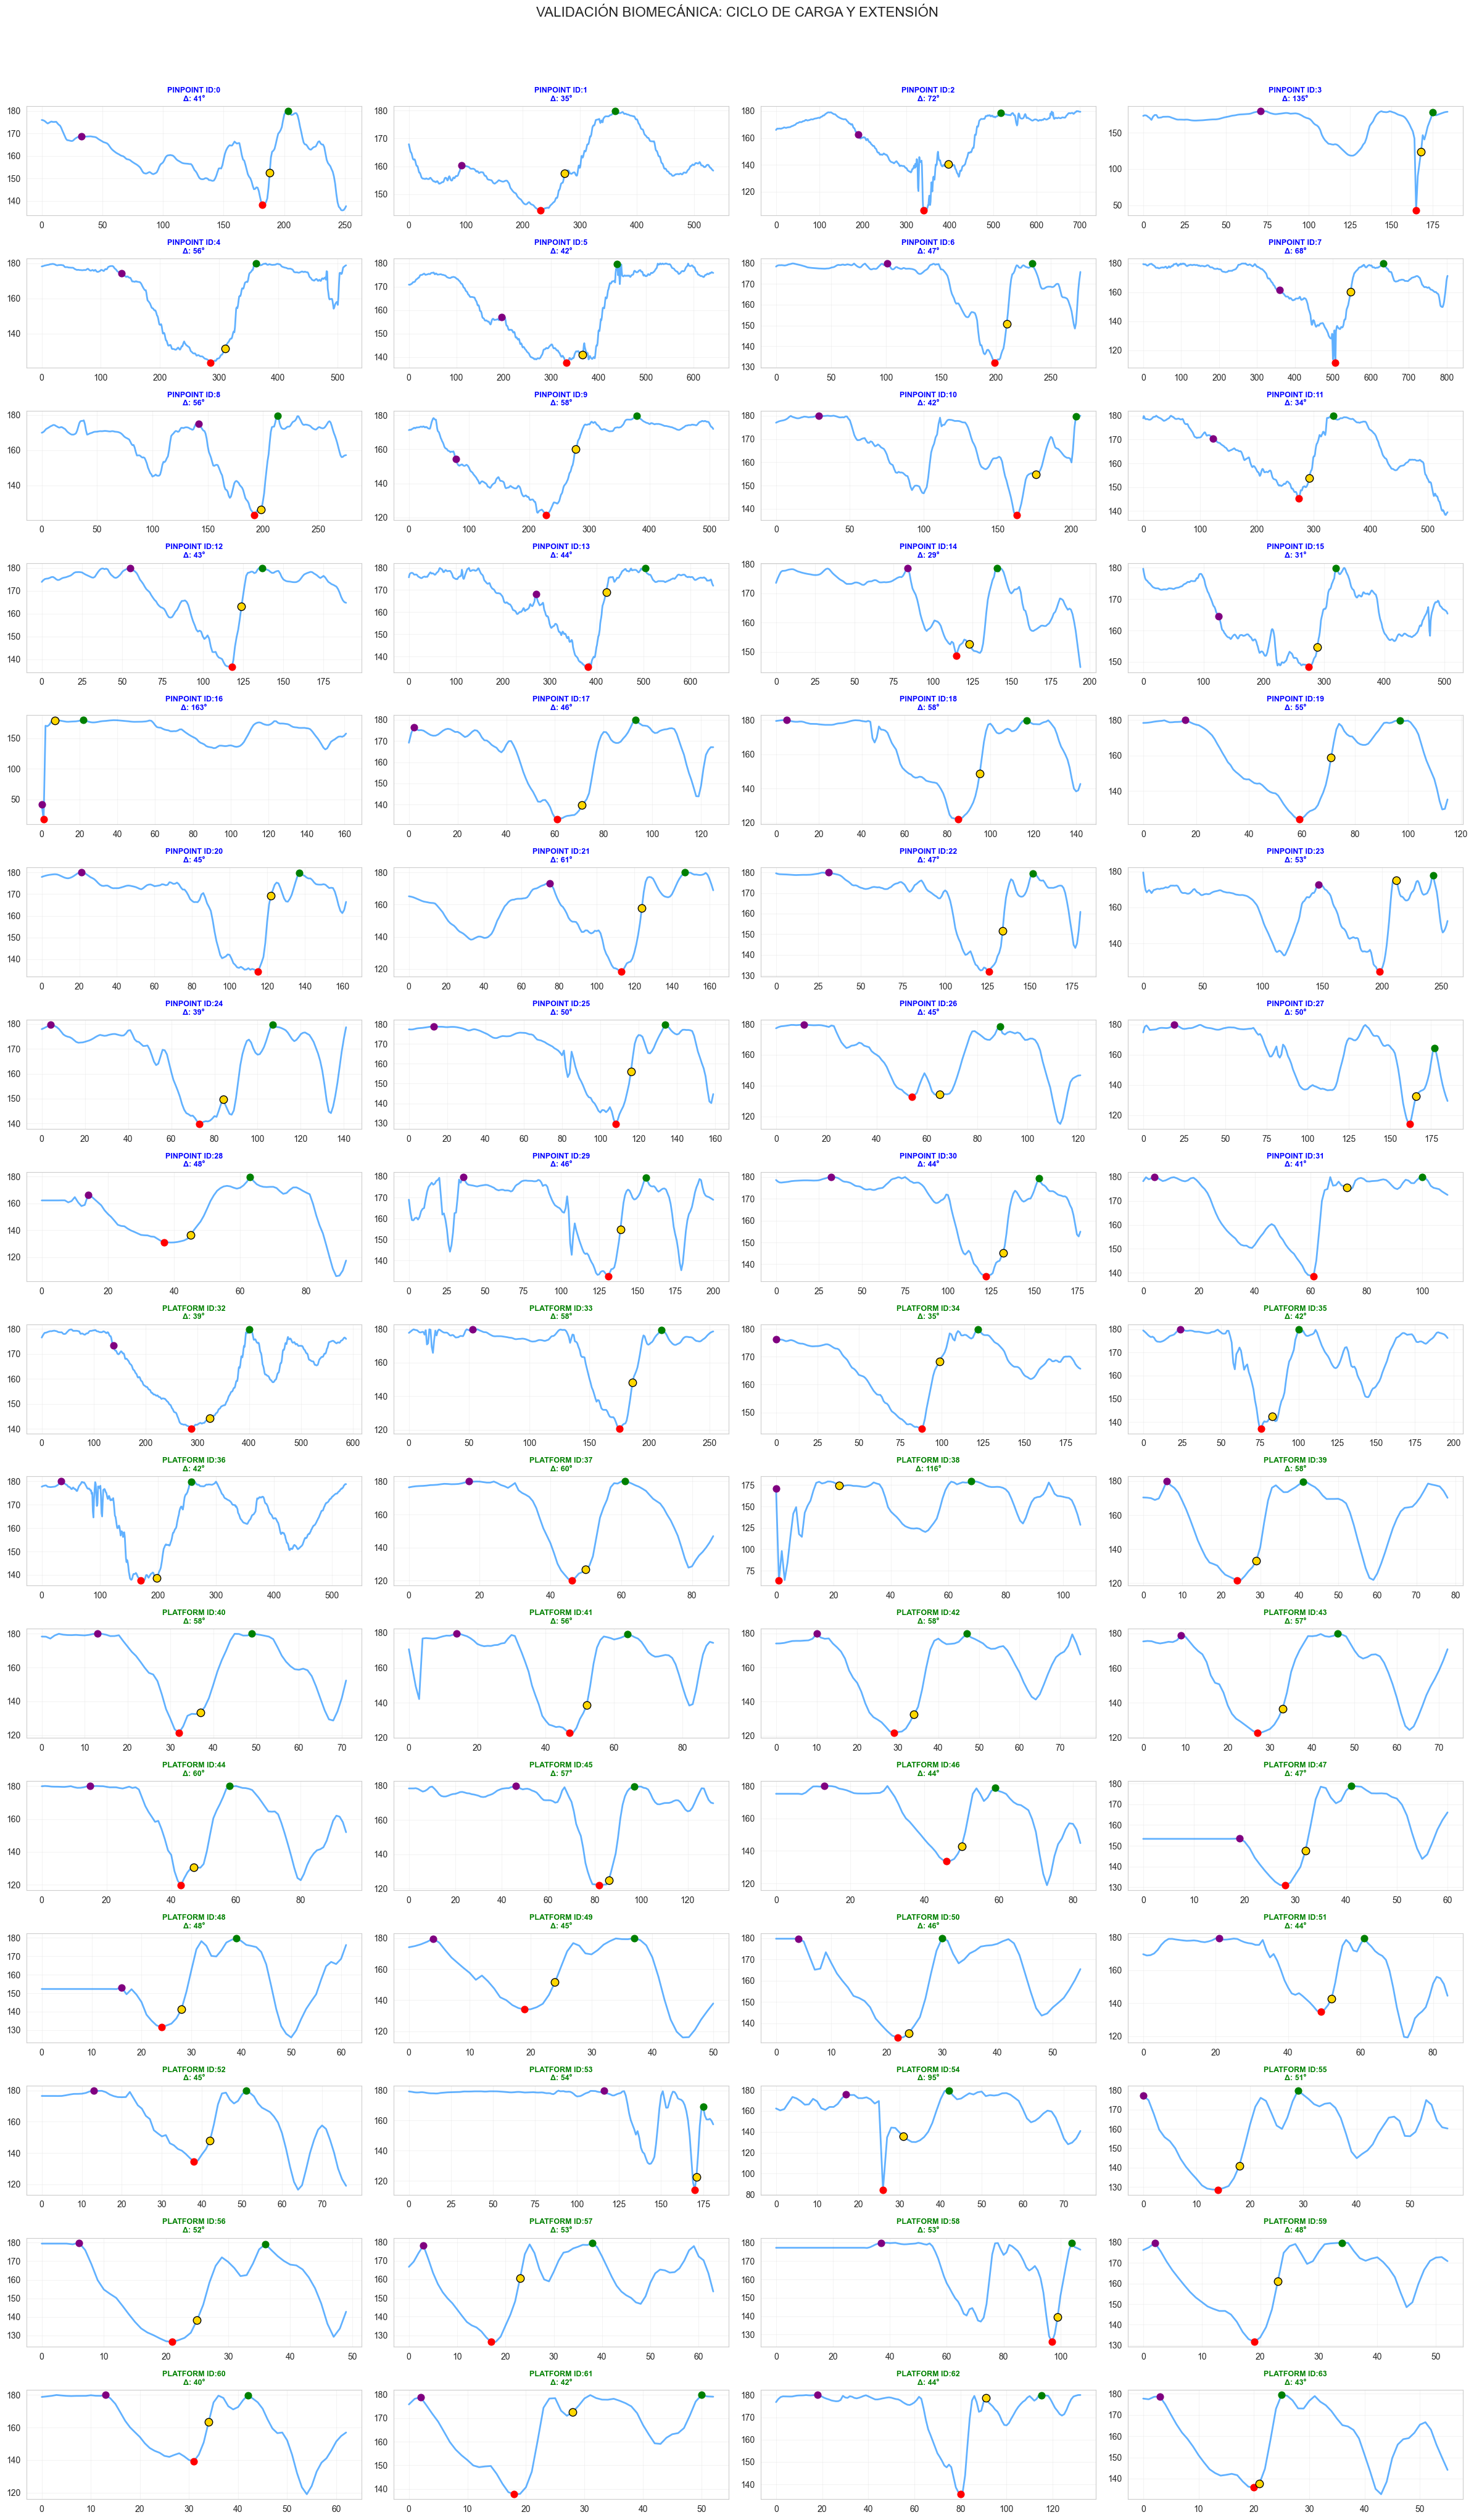

In [16]:
fig, axes = plt.subplots(nrows=16, ncols=4, figsize=(24, 40))
axes = axes.flatten() 

for idx, file_path in enumerate(selected):
    try:
        df = pd.read_csv(file_path)
        
        # 1. Calcular Ángulos
        angulos_izquierda = []
        for i in range(len(df)):
            l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
            l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
            l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
            angulos_izquierda.append(calculate_angles(l_hip, l_knee, l_ankle))
        
        df['angulo'] = angulos_izquierda
        
        # 2. Detectar Fases 
        start, min_f, max_f, target_f = detectar_fases_saque(df['angulo'])
        
        # Extraer valores para pintar
        start_val = df.loc[start, 'angulo']
        min_val = df.loc[min_f, 'angulo']
        max_val = df.loc[max_f, 'angulo']
        target_val = df.loc[target_f, 'angulo']
        
        # 3. Pintar Gráfica
        ax = axes[idx]
        
        typeof = "PINPOINT" if "pinpoint" in file_path.name.lower() else "PLATFORM"
        color = "blue" if typeof == "PINPOINT" else "green"
        
        # Línea de ángulo - Usamos el índice del DF como eje X si no existe frame_id
        x_axis = df['frame_id'] if 'frame_id' in df.columns else df.index
        ax.plot(x_axis, df['angulo'], color='dodgerblue', linewidth=2, alpha=0.7)
        
        # Puntos Clave
        ax.scatter(x_axis[start], start_val, color='purple', s=60, zorder=5, label='Inicio')
        ax.scatter(x_axis[min_f], min_val, color='red', s=60, zorder=5, label='Carga')
        ax.scatter(x_axis[target_f], target_val, color='gold', s=80, edgecolor='black', zorder=10, label='Target')
        ax.scatter(x_axis[max_f], max_val, color='green', s=60, zorder=5, label='Extensión')

        # Título y Decoración
        growth = int(max_val - min_val)
        ax.set_title(f"{typeof} ID:{idx}\nΔ: {growth}°", fontsize=9, color=color, fontweight='bold')
        ax.grid(True, alpha=0.2)
        
    except Exception as e:
        print(f"⚠️ Error en {file_path.name}: {e}")

plt.suptitle("VALIDACIÓN BIOMECÁNICA: CICLO DE CARGA Y EXTENSIÓN", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

*ANKLE DRAG*

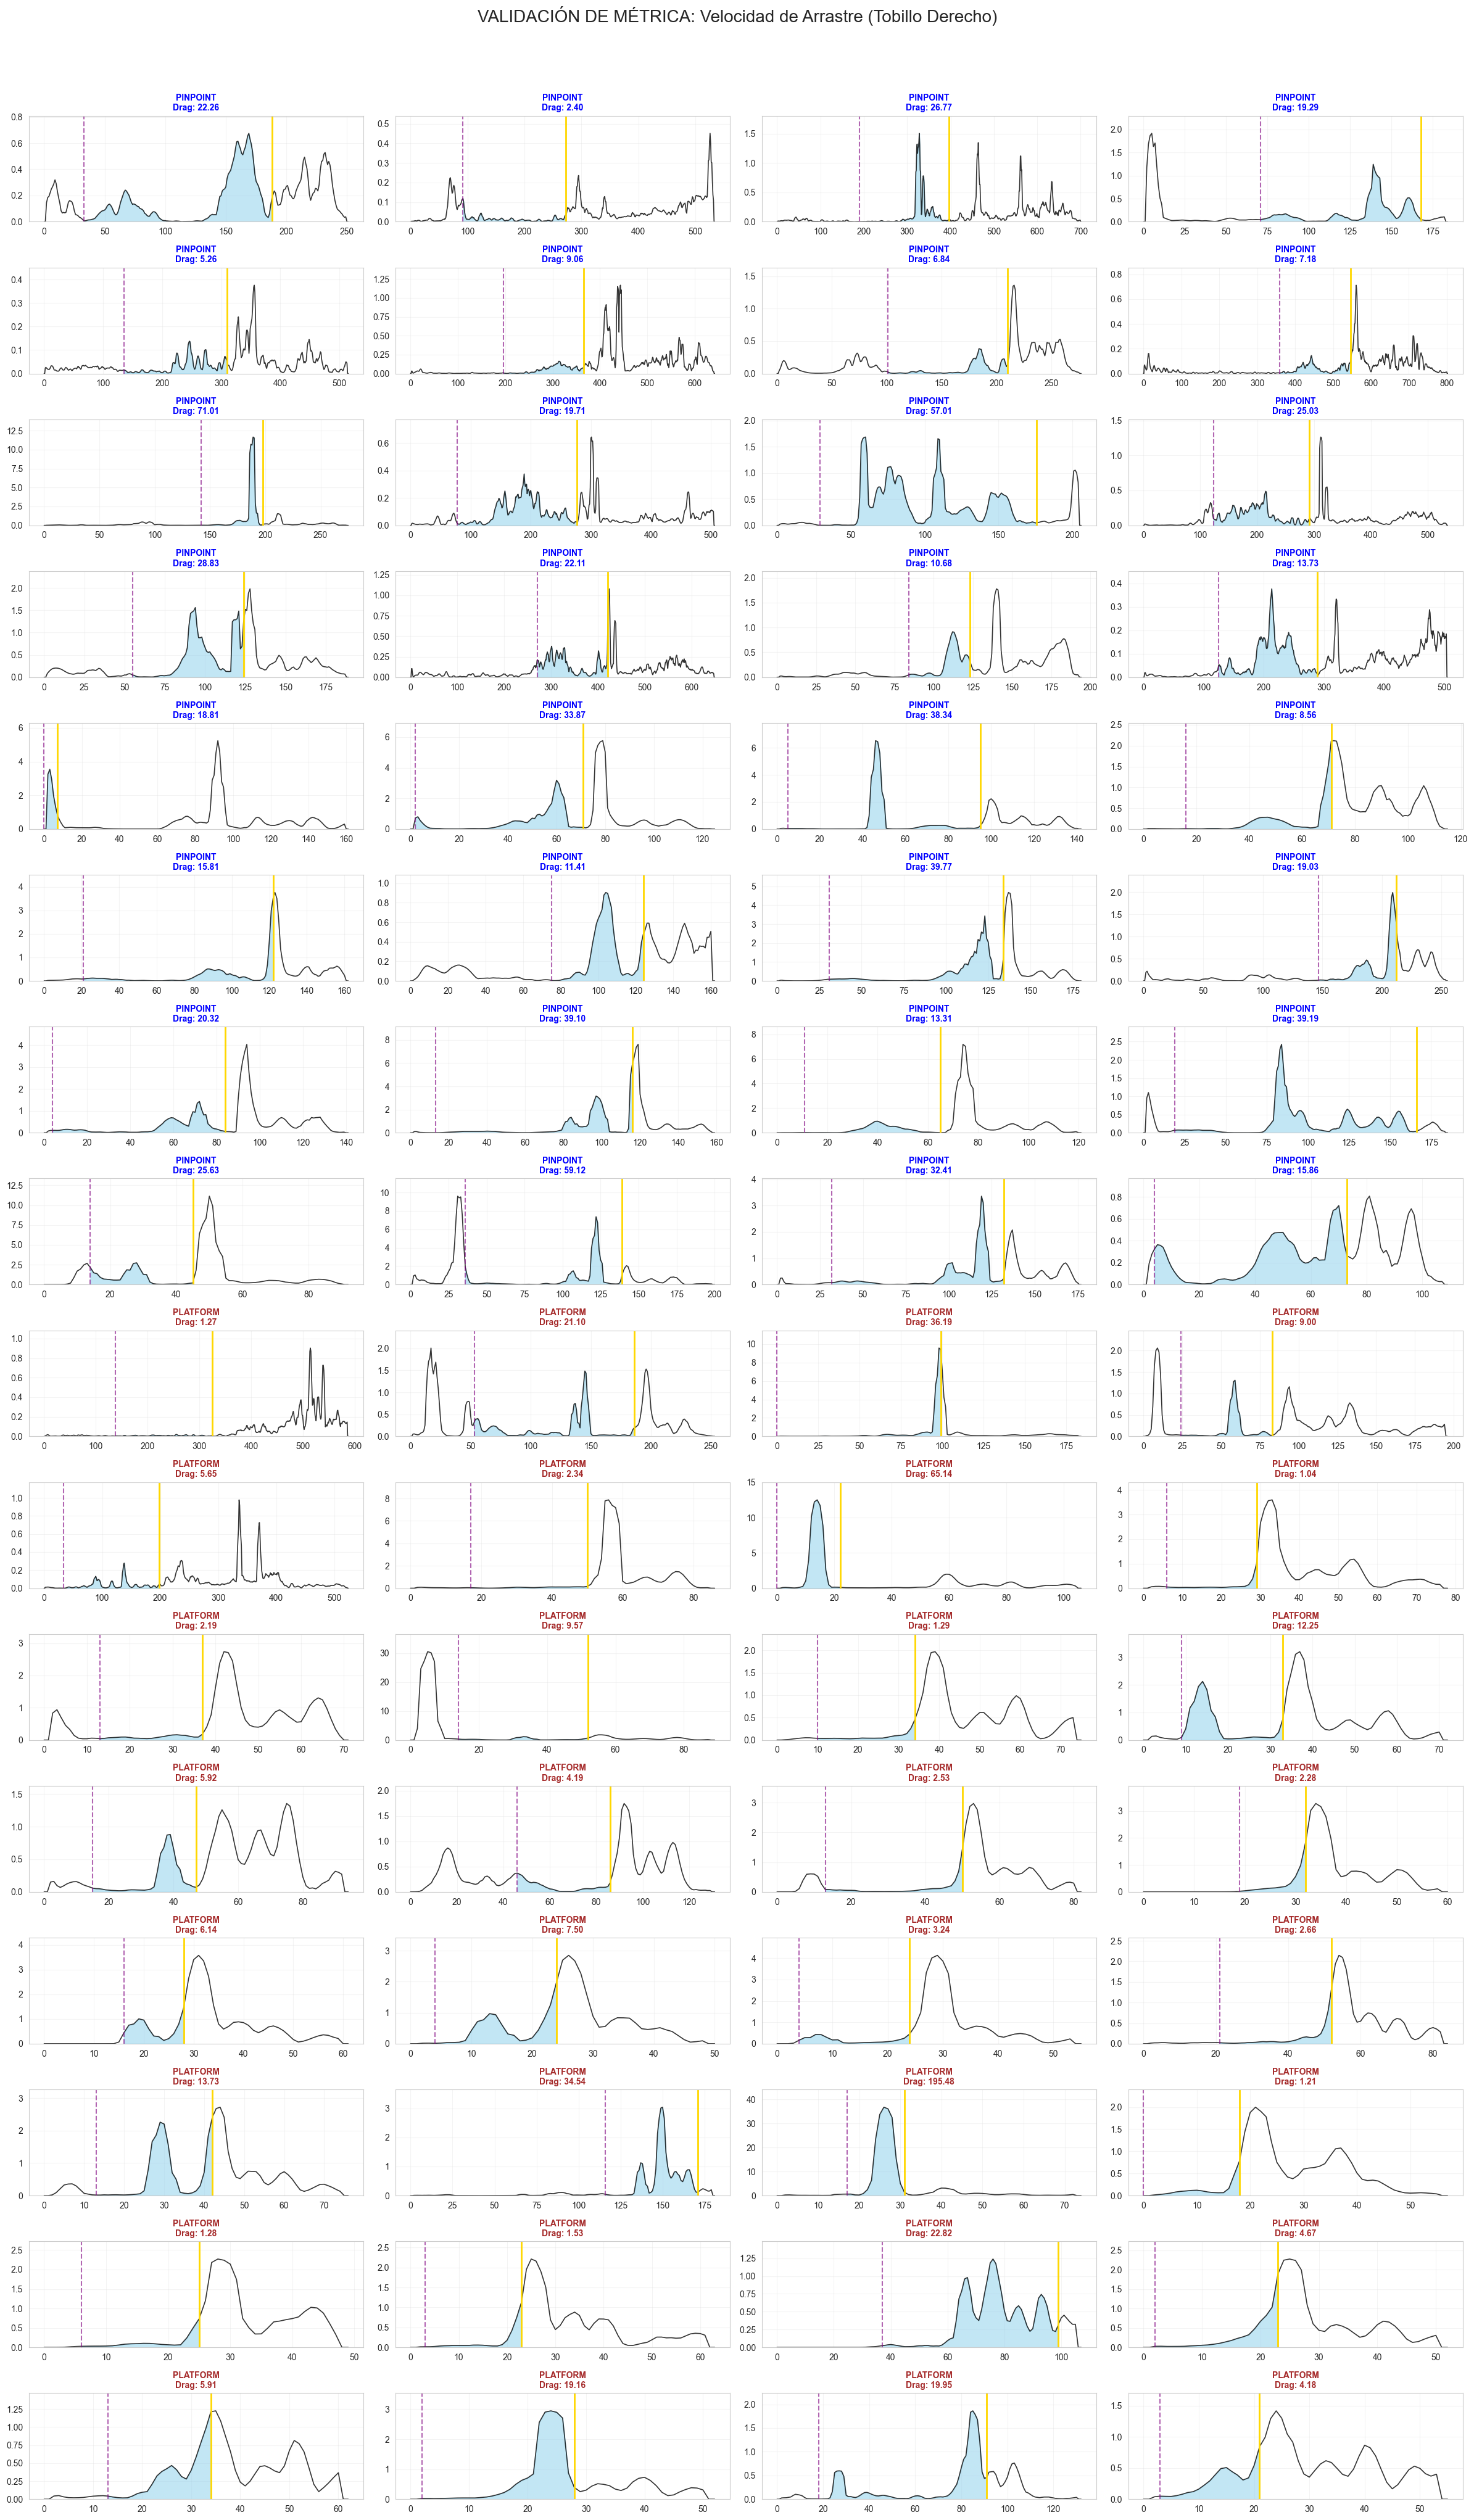

In [18]:
rows = 16
cols = 4
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(24, 40)) 
axes_flat = axes.flatten() 

for idx, file_path in enumerate(selected):
    if idx >= len(axes_flat): break 
    
    ax = axes_flat[idx] 
    
    try:
        df = pd.read_csv(file_path)
        # Aseguramos que el eje X sea consistente
        x_axis = df['frame_id'] if 'frame_id' in df.columns else df.index
        
        # 1. Calcular Ángulos y Velocidad (Normalizada)
        angulos = []
        velocidades_tobillo = [0] 
        
        for i in range(len(df)):
            # Ángulo de rodilla (usando el script modular)
            l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
            l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
            l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
            angulos.append(calculate_angles(l_hip, l_knee, l_ankle))
            
            # Velocidad del Tobillo Derecho
            if i > 0:
                curr_ankle = [df.loc[i, 'RIGHT_ANKLE_x'], df.loc[i, 'RIGHT_ANKLE_y']]
                prev_ankle = [df.loc[i-1, 'RIGHT_ANKLE_x'], df.loc[i-1, 'RIGHT_ANKLE_y']]
                
                # Usamos el ancho de cadera del frame actual para normalizar
                hip_w = get_hip_width(df, i)
                dist_px = calculate_distance(curr_ankle, prev_ankle)
                
                velocidad = dist_px / hip_w if hip_w > 0 else 0
                velocidades_tobillo.append(velocidad)
        
        df['angulo'] = angulos
        df['vel_norm'] = velocidades_tobillo
        # Suavizado para evitar picos por vibración de MediaPipe
        df['vel_smooth'] = df['vel_norm'].rolling(window=5, center=True).mean().fillna(0)
        
        # 2. Detectar Fases
        start, min_f, max_f, target_f = detectar_fases_saque(df['angulo'])
        
        # 3. Pintar Gráfica
        typeof = "PINPOINT" if "pinpoint" in file_path.name.lower() else "PLATFORM"
        color_linea = "blue" if typeof == "PINPOINT" else "brown"
        
        ax.plot(x_axis, df['vel_smooth'], color='black', linewidth=1.2, alpha=0.8)
        
        # Sombreado de la zona crítica (de Start a Target)
        # where necesita que los arrays tengan el mismo tamaño que x_axis
        mask = (x_axis >= x_axis[start]) & (x_axis <= x_axis[target_f])
        ax.fill_between(x_axis, 0, df['vel_smooth'], where=mask, color='skyblue', alpha=0.5, label='Zona Arrastre')

        # Hitos temporales
        ax.axvline(x=x_axis[start], color='purple', linestyle='--', alpha=0.6)
        ax.axvline(x=x_axis[target_f], color='gold', linewidth=2)
        
        # Métricas para el título
        drag_total = df['vel_norm'].iloc[start:target_f].sum()
        ax.set_title(f"{typeof}\nDrag: {drag_total:.2f}", fontsize=10, fontweight='bold', color=color_linea)
        
        ax.set_ylim(0, df['vel_smooth'].max() * 1.2) # Ajuste de escala dinámico
        ax.grid(True, alpha=0.2)

    except Exception as e:
        ax.text(0.5, 0.5, f"Error", ha='center', va='center', color='red')
        print(f"⚠️ Error en {file_path.name}: {e}")

plt.suptitle("VALIDACIÓN DE MÉTRICA: Velocidad de Arrastre (Tobillo Derecho)", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

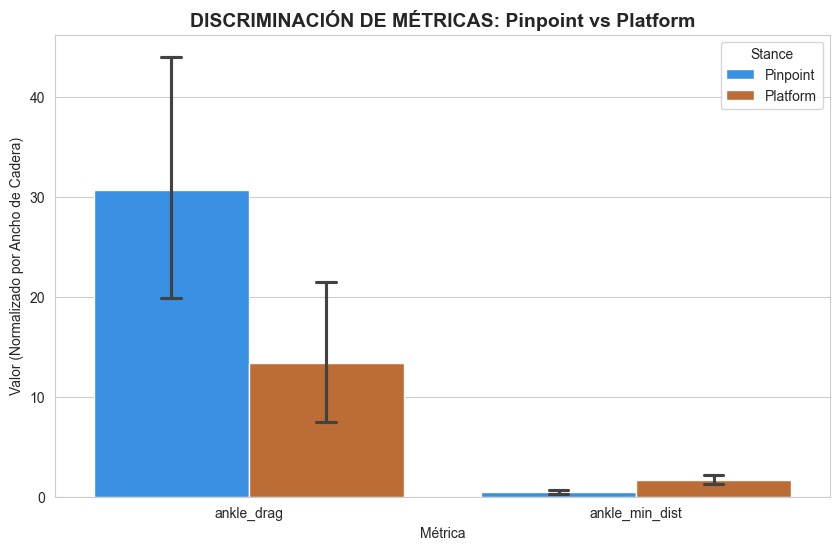

In [ ]:
stats_data = []

for file_path in selected:
    try:
        df = pd.read_csv(file_path)
        typeof = "Pinpoint" if "pinpoint" in file_path.name.lower() else "Platform"
        
        # Calcular ángulos para obtener los frames clave
        angles = [calculate_angles([r.LEFT_HIP_x, r.LEFT_HIP_y], 
                                           [r.LEFT_KNEE_x, r.LEFT_KNEE_y], 
                                           [r.LEFT_ANKLE_x, r.LEFT_ANKLE_y]) for _, r in df.iterrows()]
        
        start, _, _, target = detectar_fases_saque(angles)
        
        metrics = calculate_stance_metrics(df, start, target)
        metrics['Stance'] = typeof
        stats_data.append(metrics)
    except:
        continue

df_stats = pd.DataFrame(stats_data)

# 2. Representación Visual
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

df_melted = df_stats.melt(id_vars='Stance', value_vars=['ankle_drag', 'ankle_min_dist'], 
                          var_name='Métrica', value_name='Valor Normalizado')

ax = sns.barplot(data=df_melted, x='Métrica', y='Valor Normalizado', hue='Stance', 
                 palette={'Pinpoint': 'dodgerblue', 'Platform': 'chocolate'}, capsize=.1)

plt.title("DISCRIMINACIÓN DE MÉTRICAS: Pinpoint vs Platform", fontsize=14, fontweight='bold')
plt.ylabel("Valor (Normalizado por Ancho de Cadera)")
plt.show()